In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
df.shape

(12330, 18)

In [8]:
numerical_cols = df.select_dtypes(include = "number").columns
categorical_cols = df.select_dtypes(include = "object").columns

In [9]:
numerical_cols

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')

In [13]:
cols = ["Administrative","Administrative_Duration","Informational","Informational_Duration"]
df = df.drop(columns = cols,axis = 1)

In [14]:
df.head()

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [21]:
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Revenue', ylabel='Count'>

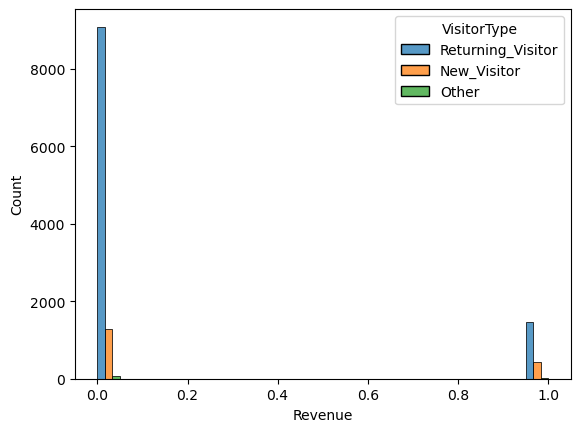

In [28]:
sns.histplot(df,x = "Revenue",hue = "VisitorType",bins = 20,multiple = "dodge")

In [31]:
cols = ["VisitorType","Weekend","Revenue"]
on =  OneHotEncoder(drop = "first",sparse_output = False,handle_unknown = "ignore")
encoded = on.fit_transform(df[cols])

In [34]:
encoded_df = pd.DataFrame(encoded,columns = on.get_feature_names_out(cols), index = df.index )

In [36]:
encoded_df

,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True,Revenue_True
0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0
...,...,...,...,...
12325,0.0,1.0,1.0,0.0
12326,0.0,1.0,1.0,0.0
12327,0.0,1.0,1.0,0.0
12328,0.0,1.0,0.0,0.0


In [38]:
df = pd.concat([df.drop(columns = cols),encoded_df],axis = 1)

In [39]:
df.head()

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True,Revenue_True
0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,0.0,1.0,0.0,0.0
1,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,0.0,1.0,0.0,0.0
2,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,0.0,1.0,0.0,0.0
3,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,0.0,1.0,0.0,0.0
4,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,0.0,1.0,1.0,0.0


In [40]:
x = df.drop("Revenue_True",axis = 1)
y = df["Revenue_True"]

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [57]:
from sklearn.tree import DecisionTreeClassifier

In [58]:
model = DecisionTreeClassifier()

In [73]:
model.fit(x_train,y_train)

ValueError: could not convert string to float: 'Mar'

In [78]:
cat = df.select_dtypes(include = "object")

In [80]:
df[cat].astype("float64")

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True,Revenue_True
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
df.head()

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True,Revenue_True
0,1,0.000000,0.20,0.20,0.0,0.0,1,1,1,1,0.0,1.0,0.0,0.0
1,2,64.000000,0.00,0.10,0.0,0.0,2,2,1,2,0.0,1.0,0.0,0.0
2,1,0.000000,0.20,0.20,0.0,0.0,4,1,9,3,0.0,1.0,0.0,0.0
3,2,2.666667,0.05,0.14,0.0,0.0,3,2,2,4,0.0,1.0,0.0,0.0
4,10,627.500000,0.02,0.05,0.0,0.0,3,3,1,4,0.0,1.0,1.0,0.0


In [70]:
df = df.drop(df.select_dtypes(include ="object"),axis = 1)

In [71]:
df.head()

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True,Revenue_True
0,1,0.000000,0.20,0.20,0.0,0.0,1,1,1,1,0.0,1.0,0.0,0.0
1,2,64.000000,0.00,0.10,0.0,0.0,2,2,1,2,0.0,1.0,0.0,0.0
2,1,0.000000,0.20,0.20,0.0,0.0,4,1,9,3,0.0,1.0,0.0,0.0
3,2,2.666667,0.05,0.14,0.0,0.0,3,2,2,4,0.0,1.0,0.0,0.0
4,10,627.500000,0.02,0.05,0.0,0.0,3,3,1,4,0.0,1.0,1.0,0.0


In [ ]:
df